# AI4QC-2 Sentinel-2 L1C (JP2) — Step-by-step debug notebook
This notebook mirrors the `s2_l1c_data.py` pipeline, but runs interactively and plots intermediate steps (as James suggested).

In [20]:
# Choose ONE tile and a date range. The notebook will:
#  1) discover all L1C products for this tile between START_DATE and END_DATE
#  2) pick one product for step-by-step debugging (DEBUG_PRODUCT_INDEX)
#  3) optionally build a time-stacked Zarr cube at the end.
#
# Notes:
# - AWS Sentinel-2 bucket uses non-zero-padded month/day in the 'products' path: .../2025/7/9/...
# - Stored data is physically meaningful reflectance = DN/10000. No percentile stretch is applied to storage.
# - Any clipping/stretching is only for plotting quicklooks.

IN_BUCKET = "sentinel-s2-l1c"

TILE = "31TCJ"                 # e.g. "56FQF"
START_DATE = "2015-06-01"      # YYYY-MM-DD (inclusive)
END_DATE   = "2025-12-31"      # YYYY-MM-DD (inclusive)
DEBUG_PRODUCT_INDEX = 0        # which product in the discovered list to use for debug plots

OUT_DIM = 128
QUANTIFICATION_VALUE = 10000.0
COVERAGE_THRESHOLD = 0.01  # fraction in [0,1]
MODE = "RGB_FLOAT"   # options: "ALL12_FLOAT", "RGB_FLOAT", "RGB_UINT16"

# Zarr output name (local). A time-stacked cube will use this name.
ZARR_NAME = f"s2_l1c_tile_{TILE}_{START_DATE}_to_{END_DATE}_{MODE}.zarr"

USE_DEBUG_DOWNSCALE = False   # True for single-product debug plots; False for bulk time stack
PID_DTYPE_LEN = 128

MAX_WORKERS = 12
DL_THREADS_PER_WORKER = 1   # 4–6 is usually enough
BATCH_SIZE = 128             # 16 or 32 recommended (optional; see section 3)
USE_BATCH_WRITES = True     # set False to keep current time=1 appends
AWS_PROFILE = "source-keys"
AWS_REGION = "eu-central-1"   # or whatever region you normally use

STAC_API_URL = "https://earth-search.aws.element84.com/v1"
L1C_COLLECTION = "sentinel-2-l1c"

ENABLE_SCENE_FILTER = True
MIN_VALID_FRACTION = 0.80   # keep only scenes with >= 80% coverage
FILTER_THREADS = 32
ON_FILTER_FAILURE = "keep"  # options: "keep", "skip", "raise"

In [21]:
BANDS_ALL12 = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B11","B12"]
BANDS_RGB   = ["B04","B03","B02"]

if MODE == "ALL12_FLOAT":
    BANDS = BANDS_ALL12
elif MODE in ("RGB_FLOAT", "RGB_UINT16"):
    BANDS = BANDS_RGB
else:
    raise ValueError(f"Unknown MODE={MODE}")


## 1) Imports

In [22]:
from __future__ import annotations

import os
import re
import json
import shutil
import tempfile
import datetime as dt
from typing import Dict, List, Optional, Tuple
from urllib.parse import urlparse, unquote
from urllib.request import urlopen

import boto3
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import Affine
from rasterio.warp import reproject
import xarray as xr
from PIL import Image

import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed

from pystac_client import Client

In [23]:
from botocore.config import Config

# MAX_WORKERS = max(1, (os.cpu_count() or 8) - 1)

S3_CONFIG = Config(
    retries={"max_attempts": 12, "mode": "adaptive"},
    connect_timeout=30,
    read_timeout=120,
)

def log_failure(log_path: str, pid: str, stage: str, err: Exception):
    rec = {
        "product_id": pid,
        "stage": stage,
        "error": repr(err),
        "ts_utc": dt.datetime.utcnow().isoformat() + "Z",
    }
    with open(log_path, "a") as f:
        f.write(json.dumps(rec) + "\n")


## 2) Helpers (same as script)

In [24]:
def parse_s3_uri(uri: str) -> Tuple[str, str]:
    if not uri.startswith("s3://"):
        raise ValueError(f"Not an s3:// URI: {uri}")
    parts = uri[5:].split("/", 1)
    bucket = parts[0]
    key = parts[1] if len(parts) > 1 else ""
    return bucket, key

def ensure_trailing_slash(s: str) -> str:
    return s if s.endswith("/") else s + "/"

def get_mgrs_tile_from_product_id(product_id: str) -> str:
    m = re.search(r"_T(\d{2}[A-Z]{3})_", product_id)
    if m:
        return m.group(1)

    legacy = re.search(r"^[A-Z0-9]+_(\d{2}[A-Z]{3})_\d{8}_\d+_L1C$", product_id)
    if legacy:
        return legacy.group(1)

    raise ValueError(f"Could not parse MGRS tile from product id: {product_id}")

def extract_datetime_token(product_id: str) -> str:
    m = re.search(r"_(\d{8}T\d{6})_", product_id)
    if m:
        return m.group(1)

    legacy = re.search(r"_(\d{8})_\d+_L1C$", product_id)
    if legacy:
        return f"{legacy.group(1)}T000000"

    raise ValueError(f"Could not extract datetime token from product id: {product_id}")

def list_s3_objects_requester_pays(s3_client, bucket: str, prefix: str) -> List[str]:
    paginator = s3_client.get_paginator("list_objects_v2")
    keys: List[str] = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix, RequestPayer="requester"):
        for obj in page.get("Contents", []):
            keys.append(obj["Key"])
    return keys

def download_s3_object_requester_pays(s3_client, bucket: str, key: str, local_path: str) -> None:
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    s3_client.download_file(bucket, key, local_path, ExtraArgs={"RequestPayer": "requester"})

def _is_bad_key(k: str) -> bool:
    kl = k.lower()
    base = os.path.basename(kl)
    if not kl.endswith(".jp2"):
        return True
    if "/preview/" in kl:
        return True
    if "/qi_data/" in kl or "/aux_data/" in kl:
        return True
    if base.startswith("msk") or "msk" in base or "mask" in base:
        return True
    if base == "tci.jp2" or base.endswith("_tci.jp2"):
        return True
    return False

BAND_RES = {
    "B01": "R60m",
    "B02": "R10m",
    "B03": "R10m",
    "B04": "R10m",
    "B05": "R20m",
    "B06": "R20m",
    "B07": "R20m",
    "B08": "R10m",
    "B8A": "R20m",
    "B09": "R60m",
    "B10": "R60m",
    "B11": "R20m",
    "B12": "R20m",
}

def find_jp2_band_keys(all_keys: List[str], bands: List[str]) -> Dict[str, str]:
    keys = [k for k in all_keys if not _is_bad_key(k)]

    def matches_band(k: str, band: str) -> bool:
        base = os.path.basename(k)
        return base == f"{band}.jp2" or base.endswith(f"_{band}.jp2")

    band_to_key: Dict[str, str] = {}
    for band in bands:
        # print(f"Looking for band {band}")
        candidates = [k for k in keys if matches_band(k, band)]
        if not candidates:
            some = sorted({os.path.basename(x) for x in keys})[:30]
            raise RuntimeError(
                f"No JP2 found for band {band} after filtering. Example JP2 basenames seen: {some}"
            )

        want_res = BAND_RES.get(band)
        if want_res:
            res_candidates = [k for k in candidates if f"/{want_res.lower()}/" in k.lower()]
            if res_candidates:
                band_to_key[band] = sorted(res_candidates, key=len)[0]
                continue

        band_to_key[band] = sorted(candidates, key=len)[0]

    return band_to_key

def log_mask_and_dtype(jp2_path: str) -> None:
    with rasterio.open(jp2_path) as src:
        mask_flags = src.mask_flag_enums[0] if src.count >= 1 else []
        print(f"[{os.path.basename(jp2_path)}] dtype={src.dtypes[0]} nodata={src.nodata} mask_flags={mask_flags}")
        m = src.read_masks(1, out_shape=(min(64, src.height), min(64, src.width)))
        print(f"[{os.path.basename(jp2_path)}] mask sample unique={np.unique(m)[:10]}")

def tile_to_tiles_prefix(tile: str, sensing_date: dt.date) -> str:
    utm = tile[:2]
    lat = tile[2]
    grid = tile[3:]
    y = f"{sensing_date.year:04d}"
    m = str(sensing_date.month)
    d = str(sensing_date.day)
    return f"tiles/{utm}/{lat}/{grid}/{y}/{m}/{d}/"

def sensing_date_from_product_id(product_id: str) -> dt.date:
    tok = extract_datetime_token(product_id)  # YYYYMMDDThhmmss
    return dt.datetime.strptime(tok, "%Y%m%dT%H%M%S").date()


In [25]:
# Process-local cached boto3 session/client for worker reuse
_PROCESS_BOTO_SESSION = None
_PROCESS_S3_CLIENT = None

def get_process_s3_client():
    global _PROCESS_BOTO_SESSION, _PROCESS_S3_CLIENT

    if _PROCESS_S3_CLIENT is None:
        _PROCESS_BOTO_SESSION = boto3.Session(
            profile_name=AWS_PROFILE,
            region_name=AWS_REGION
        )
        _PROCESS_S3_CLIENT = _PROCESS_BOTO_SESSION.client("s3", config=S3_CONFIG)

    return _PROCESS_S3_CLIENT

In [26]:
def iter_dates(start_date: str, end_date: str) -> List[dt.date]:
    s = dt.date.fromisoformat(start_date)
    e = dt.date.fromisoformat(end_date)
    if e < s:
        raise ValueError("END_DATE must be >= START_DATE")
    out = []
    d = s
    while d <= e:
        out.append(d)
        d += dt.timedelta(days=1)
    return out

def safe_prefix_to_product_id(safe_prefix: str) -> str:
    pid = safe_prefix.rstrip("/").split("/")[-1]
    if pid.endswith(".SAFE"):
        pid = pid[:-5]
    return pid

def sensing_time_from_product_id(product_id: str) -> np.datetime64:
    tok = extract_datetime_token(product_id)
    dt_obj = dt.datetime.strptime(tok, "%Y%m%dT%H%M%S")
    return np.datetime64(dt_obj, "ns")

def parse_tile(tile: str) -> Tuple[int, str, str]:
    tile = tile.strip().upper()
    return int(tile[:2]), tile[2], tile[3:]

ASSET_KEY_FOR_BAND: Dict[str, str] = {
    "B01": "coastal",
    "B02": "blue",
    "B03": "green",
    "B04": "red",
    "B05": "rededge1",
    "B06": "rededge2",
    "B07": "rededge3",
    "B08": "nir",
    "B8A": "nir08",
    "B09": "nir09",
    "B11": "swir16",
    "B12": "swir22",
}

def normalize_l1c_band_href(href: str, expected_bucket: str) -> str:
    if href.startswith("s3://sentinel-s2-l2a/"):
        return "s3://" + expected_bucket + "/" + href[len("s3://sentinel-s2-l2a/"):]
    return href

def normalize_http_to_s3_if_possible(href: str, expected_bucket: Optional[str] = None) -> str:
    if href.startswith("s3://"):
        return href

    parsed = urlparse(href)
    if parsed.scheme not in {"http", "https"}:
        return href

    host = parsed.netloc
    path = unquote(parsed.path.lstrip("/"))

    if expected_bucket and host.startswith(f"{expected_bucket}.s3"):
        return f"s3://{expected_bucket}/{path}"

    if host.startswith("s3") and expected_bucket and path.startswith(expected_bucket + "/"):
        return f"s3://{path}"

    return href

def safe_float(v: object) -> Optional[float]:
    if v is None:
        return None
    try:
        return float(v)
    except Exception:
        return None

def normalize_key(k: object) -> str:
    return "".join(ch.lower() for ch in str(k) if ch.isalnum())

def recursive_find_value(obj: object, target_keys: List[str]) -> Optional[object]:
    targets = {normalize_key(k) for k in target_keys}

    def _walk(x: object) -> Optional[object]:
        if isinstance(x, dict):
            for k, v in x.items():
                if normalize_key(k) in targets:
                    return v
            for v in x.values():
                hit = _walk(v)
                if hit is not None:
                    return hit
        elif isinstance(x, list):
            for v in x:
                hit = _walk(v)
                if hit is not None:
                    return hit
        return None

    return _walk(obj)

def try_fetch_json(uri: str, s3_client, requester_pays_buckets: Optional[set] = None) -> dict:
    requester_pays_buckets = requester_pays_buckets or set()

    if uri.startswith("s3://"):
        bucket, key = parse_s3_uri(uri)
        extra = {"RequestPayer": "requester"} if bucket in requester_pays_buckets else {}
        obj = s3_client.get_object(Bucket=bucket, Key=key, **extra)
        body = obj["Body"]
        try:
            return json.loads(body.read())
        finally:
            body.close()

    if uri.startswith("http://") or uri.startswith("https://"):
        with urlopen(uri, timeout=10) as resp:
            return json.loads(resp.read().decode("utf-8"))

    with open(uri, "rb") as f:
        return json.loads(f.read().decode("utf-8"))

def fetch_l1c_coverage_pct(tileinfo_uri: str, s3_client) -> Optional[float]:
    info = try_fetch_json(tileinfo_uri, s3_client, requester_pays_buckets={"sentinel-s2-l1c", "sentinel-s2-l2a"})
    cov = safe_float(
        recursive_find_value(
            info,
            ["dataCoveragePercentage", "data_coverage_percentage", "dataCoverage"]
        )
    )
    return cov

def discover_l1c_scene_records(
    stac_api_url: str,
    collection: str,
    tile: str,
    start_date: str,
    end_date: str,
    bands: List[str],
    expected_bucket: str,
) -> List[dict]:
    utm, lat_band, grid_square = parse_tile(tile)

    client = Client.open(stac_api_url)
    search = client.search(
        collections=[collection],
        datetime=f"{start_date}/{end_date}",
        query={
            "mgrs:utm_zone": {"eq": utm},
            "mgrs:latitude_band": {"eq": lat_band},
            "mgrs:grid_square": {"eq": grid_square},
        },
    )

    items = list(search.items())
    items.sort(key=lambda it: (it.datetime, it.id))

    out: List[dict] = []
    for it in items:
        if it.datetime is None:
            continue

        assets = it.assets
        band_hrefs: Dict[str, str] = {}

        for band in bands:
            asset_key = ASSET_KEY_FOR_BAND[band]
            asset = assets.get(asset_key)
            if asset is None or not asset.href:
                raise KeyError(f"Missing asset {asset_key} for item {it.id}")

            href = normalize_http_to_s3_if_possible(asset.href, expected_bucket=expected_bucket)
            href = normalize_l1c_band_href(href, expected_bucket=expected_bucket)

            if not href.startswith("s3://"):
                raise ValueError(f"Band href is not s3:// for {it.id} {band}: {href}")

            band_hrefs[band] = href

        tileinfo_asset = assets.get("tileinfo_metadata")
        tileinfo_uri = tileinfo_asset.href if (tileinfo_asset and tileinfo_asset.href) else None

        out.append({
            "product_id": it.id,
            "datetime": sensing_time_from_product_id(it.id),
            "band_hrefs": band_hrefs,
            "l1c_tileinfo_uri": tileinfo_uri,
        })

    return out

def dedup_scene_records(scene_records: List[dict]) -> List[dict]:
    seen = set()
    unique = []
    for rec in scene_records:
        pid = rec["product_id"]
        if pid not in seen:
            seen.add(pid)
            unique.append(rec)
    return unique

def filter_one_scene_by_l1c_coverage(scene_rec: dict, s3_client, min_valid_fraction: float, on_failure: str = "keep") -> dict:
    threshold_pct = float(min_valid_fraction * 100.0)
    tileinfo_uri = scene_rec.get("l1c_tileinfo_uri")

    try:
        if not tileinfo_uri:
            raise FileNotFoundError("L1C tileinfo_metadata asset missing")

        coverage_pct = fetch_l1c_coverage_pct(tileinfo_uri, s3_client)
        if coverage_pct is None:
            raise KeyError("dataCoveragePercentage missing in tileinfo metadata")

        keep = coverage_pct >= threshold_pct

        out = dict(scene_rec)
        out["coverage_pct"] = coverage_pct
        out["filter_keep"] = keep
        out["filter_source"] = "l1c_tileinfo"
        out["filter_note"] = None
        return out

    except Exception as e:
        if on_failure == "keep":
            out = dict(scene_rec)
            out["coverage_pct"] = None
            out["filter_keep"] = True
            out["filter_source"] = "filter_error_keep"
            out["filter_note"] = repr(e)
            return out

        if on_failure == "skip":
            out = dict(scene_rec)
            out["coverage_pct"] = None
            out["filter_keep"] = False
            out["filter_source"] = "filter_error_skip"
            out["filter_note"] = repr(e)
            return out

        raise

def filter_scene_records_by_l1c_coverage(
    scene_records: List[dict],
    s3_client,
    min_valid_fraction: float,
    max_workers: int = 32,
    on_failure: str = "keep",
):
    kept = []
    skipped = []
    threshold_pct = float(min_valid_fraction * 100.0)

    def _work(rec):
        return filter_one_scene_by_l1c_coverage(
            rec,
            s3_client=s3_client,
            min_valid_fraction=min_valid_fraction,
            on_failure=on_failure,
        )

    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(_work, rec) for rec in scene_records]
        for i, fut in enumerate(as_completed(futures), start=1):
            results.append(fut.result())
            if i % 100 == 0 or i == len(scene_records):
                print(f"[filter] {i}/{len(scene_records)} scene metadata checks complete")

    results_by_pid = {rec["product_id"]: rec for rec in results}

    ordered_results = [results_by_pid[rec["product_id"]] for rec in scene_records]

    for rec in ordered_results:
        if rec["filter_keep"]:
            kept.append(rec)
        else:
            skipped.append(rec)

    stats = {
        "n_total": len(scene_records),
        "n_kept": len(kept),
        "n_skipped": len(skipped),
        "threshold_pct": threshold_pct,
        "source_counts": {},
    }

    for rec in ordered_results:
        src = rec["filter_source"]
        stats["source_counts"][src] = stats["source_counts"].get(src, 0) + 1

    return kept, skipped, stats

## 3) Locate and download JP2s (Requester Pays)
This mirrors your `process_one_safe` selection logic, but keeps files locally so we can plot intermediate arrays.

In [27]:
session = boto3.Session(
    profile_name=AWS_PROFILE,
    region_name=AWS_REGION
)

s3 = session.client("s3", config=S3_CONFIG)

cache_dir = "cache"
os.makedirs(cache_dir, exist_ok=True)
cache_path = os.path.join(
    cache_dir,
    f"scene_records_{TILE}_{START_DATE}_{END_DATE}_{MODE}_filter_{int(ENABLE_SCENE_FILTER)}_{str(MIN_VALID_FRACTION).replace('.', 'p')}.json"
)

if os.path.exists(cache_path):
    with open(cache_path, "r") as f:
        raw_scene_records = json.load(f)

    scene_records = []
    for rec in raw_scene_records:
        out = {
            "product_id": rec["product_id"],
            "datetime": np.datetime64(rec["datetime"], "ns"),
            "band_hrefs": rec["band_hrefs"],
            "l1c_tileinfo_uri": rec.get("l1c_tileinfo_uri"),
            "coverage_pct": rec.get("coverage_pct"),
            "filter_keep": rec.get("filter_keep"),
            "filter_source": rec.get("filter_source"),
            "filter_note": rec.get("filter_note"),
        }
        scene_records.append(out)

    print(f"Loaded cached scene records: {len(scene_records)} from {cache_path}")

else:
    scene_records = discover_l1c_scene_records(
        stac_api_url=STAC_API_URL,
        collection=L1C_COLLECTION,
        tile=TILE,
        start_date=START_DATE,
        end_date=END_DATE,
        bands=BANDS,
        expected_bucket=IN_BUCKET,
    )

    scene_records = dedup_scene_records(scene_records)
    print("Discovered scene records before filter:", len(scene_records))

    if ENABLE_SCENE_FILTER:
        kept, skipped, filter_stats = filter_scene_records_by_l1c_coverage(
            scene_records=scene_records,
            s3_client=s3,
            min_valid_fraction=MIN_VALID_FRACTION,
            max_workers=FILTER_THREADS,
            on_failure=ON_FILTER_FAILURE,
        )
        print("Filter stats:", json.dumps(filter_stats, indent=2))
        print(f"Kept {len(kept)} scenes, skipped {len(skipped)} scenes")
        scene_records = kept
    else:
        print("Scene filtering disabled")

    raw_scene_records = []
    for rec in scene_records:
        raw_scene_records.append({
            "product_id": rec["product_id"],
            "datetime": str(rec["datetime"]),
            "band_hrefs": rec["band_hrefs"],
            "l1c_tileinfo_uri": rec.get("l1c_tileinfo_uri"),
            "coverage_pct": rec.get("coverage_pct"),
            "filter_keep": rec.get("filter_keep"),
            "filter_source": rec.get("filter_source"),
            "filter_note": rec.get("filter_note"),
        })

    with open(cache_path, "w") as f:
        json.dump(raw_scene_records, f)

    print(f"Discovered and cached filtered scene records: {len(scene_records)} to {cache_path}")

scene_records = dedup_scene_records(scene_records)
print("Scene records after dedup:", len(scene_records))

scene_records[:2]

Loaded cached scene records: 667 from cache/scene_records_31TCJ_2015-06-01_2025-12-31_RGB_FLOAT_filter_1_0p8.json
Scene records after dedup: 667


[{'product_id': 'S2A_31TCJ_20161107_0_L1C',
  'datetime': np.datetime64('2016-11-07T00:00:00.000000000'),
  'band_hrefs': {'B04': 's3://sentinel-s2-l1c/tiles/31/T/CJ/2016/11/7/0/B04.jp2',
   'B03': 's3://sentinel-s2-l1c/tiles/31/T/CJ/2016/11/7/0/B03.jp2',
   'B02': 's3://sentinel-s2-l1c/tiles/31/T/CJ/2016/11/7/0/B02.jp2'},
  'l1c_tileinfo_uri': 's3://sentinel-s2-l2a/tiles/31/T/CJ/2016/11/7/0/tileInfo.json',
  'coverage_pct': 100.0,
  'filter_keep': True,
  'filter_source': 'l1c_tileinfo',
  'filter_note': None},
 {'product_id': 'S2A_31TCJ_20161117_0_L1C',
  'datetime': np.datetime64('2016-11-17T00:00:00.000000000'),
  'band_hrefs': {'B04': 's3://sentinel-s2-l1c/tiles/31/T/CJ/2016/11/17/0/B04.jp2',
   'B03': 's3://sentinel-s2-l1c/tiles/31/T/CJ/2016/11/17/0/B03.jp2',
   'B02': 's3://sentinel-s2-l1c/tiles/31/T/CJ/2016/11/17/0/B02.jp2'},
  'l1c_tileinfo_uri': 's3://sentinel-s2-l2a/tiles/31/T/CJ/2016/11/17/0/tileInfo.json',
  'coverage_pct': 100.0,
  'filter_keep': True,
  'filter_source': 

In [28]:
for rec in scene_records[:20]:
    print(
        rec["product_id"],
        "| coverage_pct=", rec.get("coverage_pct"),
        "| filter_source=", rec.get("filter_source")
    )

if not scene_records:
    raise RuntimeError("No scenes found for the requested tile/date range after filtering.")

scene = scene_records[DEBUG_PRODUCT_INDEX]
product_id = scene["product_id"]
band_hrefs = scene["band_hrefs"]
tile = get_mgrs_tile_from_product_id(product_id)

dt_token = extract_datetime_token(product_id)
print("DEBUG product_id:", product_id)
print("DEBUG sensing token:", dt_token)
print("DEBUG coverage_pct:", scene.get("coverage_pct"))
print("DEBUG filter_source:", scene.get("filter_source"))

S2A_31TCJ_20161107_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20161117_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20161127_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20161207_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20161217_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20161227_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20170116_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20170126_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20170205_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20170215_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20170225_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20170307_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo
S2A_31TCJ_20170317_0_L1C | coverage_pct= 100.0 | filter_source= l1c_tileinfo

In [29]:
tmp = tempfile.mkdtemp(prefix="ai4qc2_nb_")
local_safe_dir = os.path.join(tmp, product_id)
os.makedirs(local_safe_dir, exist_ok=True)

band_local_paths: Dict[str, str] = {}
for band, href in band_hrefs.items():
    bucket, key = parse_s3_uri(href)
    local_path = os.path.join(local_safe_dir, os.path.basename(key))
    download_s3_object_requester_pays(s3, bucket, key, local_path)
    band_local_paths[band] = local_path

tmp, list(band_local_paths.items())[:3]

('/tmp/ai4qc2_nb_04hss_4b',
 [('B04', '/tmp/ai4qc2_nb_04hss_4b/S2A_31TCJ_20161107_0_L1C/B04.jp2'),
  ('B03', '/tmp/ai4qc2_nb_04hss_4b/S2A_31TCJ_20161107_0_L1C/B03.jp2'),
  ('B02', '/tmp/ai4qc2_nb_04hss_4b/S2A_31TCJ_20161107_0_L1C/B02.jp2')])

## 4) Visualise raw DN + raw mask for one band
Pick a band and inspect raw statistics and a downsampled preview.

In [30]:
BAND_FOR_DEBUG = "B02"  # change if you want
jp2_path = band_local_paths[BAND_FOR_DEBUG]

log_mask_and_dtype(jp2_path)

with rasterio.open(jp2_path) as src:
    dn = src.read(1)  # uint16 DN
    mask_u8 = src.read_masks(1)  # uint8 mask 0/255

print("DN stats:", "min", int(dn.min()), "max", int(dn.max()), "zero_frac", float((dn==0).mean()))
print("Mask stats:", "unique", np.unique(mask_u8)[:10], "valid_frac", float((mask_u8>0).mean()))


[B02.jp2] dtype=uint16 nodata=None mask_flags=[<MaskFlags.all_valid: 1>]
[B02.jp2] mask sample unique=[255]
DN stats: min 931 max 14688 zero_frac 0.0
Mask stats: unique [255] valid_frac 1.0


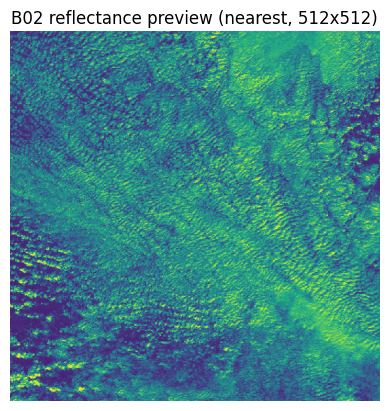

In [31]:
# Quick preview: show a heavily downsampled view for speed
with rasterio.open(jp2_path) as src:
    preview = src.read(1, out_shape=(512,512), resampling=Resampling.nearest).astype(np.float32) / QUANTIFICATION_VALUE

plt.figure()
plt.title(f"{BAND_FOR_DEBUG} reflectance preview (nearest, 512x512)")
plt.imshow(np.clip(preview, 0, 1))
plt.axis("off")
plt.show()


## 5) Masked-mean downscaling internals
We plot each intermediate: `valid`, `num`, `den`, `dst_den`, and final reflectance.

In [32]:
def masked_mean_downscale_debug(
    jp2_path: str,
    out_dim: int,
    quantification_value: float,
    *,
    band_index: int = 1,
    coverage_threshold: float = 0.0,
    resampling: Resampling = Resampling.average,
):
    with rasterio.open(jp2_path) as src:
        crs = src.crs
        src_transform = src.transform
        scale_x = src.width / out_dim
        scale_y = src.height / out_dim
        dst_transform = src_transform * Affine.scale(scale_x, scale_y)

        data = src.read(band_index).astype(np.float32)
        valid = (src.read_masks(band_index) > 0).astype(np.float32)  # 0/1
        num = data * valid
        den = valid

        dst_num = np.zeros((out_dim, out_dim), dtype=np.float32)
        dst_den = np.zeros((out_dim, out_dim), dtype=np.float32)

        reproject(
            source=num,
            destination=dst_num,
            src_transform=src_transform,
            src_crs=crs,
            dst_transform=dst_transform,
            dst_crs=crs,
            resampling=resampling,
        )
        reproject(
            source=den,
            destination=dst_den,
            src_transform=src_transform,
            src_crs=crs,
            dst_transform=dst_transform,
            dst_crs=crs,
            resampling=resampling,
        )

    with np.errstate(divide="ignore", invalid="ignore"):
        out_dn = dst_num / dst_den

    out_ref = out_dn / float(quantification_value)
    out_ref[dst_den <= max(coverage_threshold, 1e-12)] = np.nan

    return {
        "data_dn": data,
        "valid_01": valid,
        "num_dn": num,
        "den": den,
        "dst_num": dst_num,
        "dst_den": dst_den,
        "out_dn": out_dn,
        "out_ref": out_ref,
        "crs": crs,
        "dst_transform": dst_transform,
    }

dbg = masked_mean_downscale_debug(
    jp2_path,
    OUT_DIM,
    QUANTIFICATION_VALUE,
    coverage_threshold=COVERAGE_THRESHOLD,
    resampling=Resampling.average,
)

print("dst_den stats:", "min", float(np.nanmin(dbg["dst_den"])), "max", float(np.nanmax(dbg["dst_den"])))
print("out_ref stats:", "min", float(np.nanmin(dbg["out_ref"])), "max", float(np.nanmax(dbg["out_ref"])))
print("out_ref zero_frac:", float((np.nan_to_num(dbg["out_ref"])==0).mean()))


dst_den stats: min 1.0 max 1.0
out_ref stats: min 0.10117316246032715 max 0.911670982837677
out_ref zero_frac: 0.0


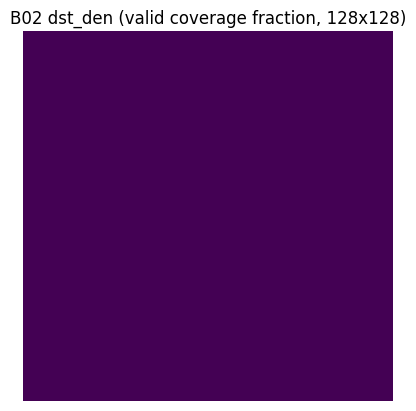

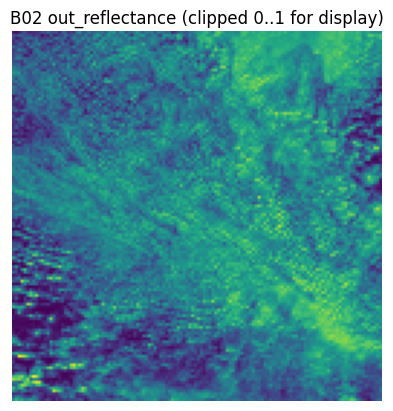

In [33]:
# Plot dst_den (coverage) and output reflectance
plt.figure()
plt.title(f"{BAND_FOR_DEBUG} dst_den (valid coverage fraction, {OUT_DIM}x{OUT_DIM})")
plt.imshow(dbg["dst_den"])
plt.axis("off")
plt.show()

plt.figure()
plt.title(f"{BAND_FOR_DEBUG} out_reflectance (clipped 0..1 for display)")
plt.imshow(np.clip(dbg["out_ref"], 0, 1))
plt.axis("off")
plt.show()


## 6) Build RGB quicklook from the cube (B04/B03/B02)
This reproduces your `write_quicklook_b432_rgba` logic, but displays inline.

[[[0.1239 0.1339 0.166 ]
  [0.0722 0.0943 0.1297]
  [0.0831 0.1022 0.1402]
  ...
  [0.5068 0.4822 0.5334]
  [0.5003 0.4757 0.527 ]
  [0.476  0.4531 0.5045]]

 [[0.2672 0.2618 0.2977]
  [0.2089 0.2112 0.2425]
  [0.3314 0.3194 0.3522]
  ...
  [0.6445 0.5911 0.6282]
  [0.6328 0.5807 0.6192]
  [0.6533 0.5983 0.6389]]

 [[0.2982 0.2803 0.3065]
  [0.1384 0.1471 0.1793]
  [0.1563 0.1641 0.1934]
  ...
  [0.5568 0.5155 0.5536]
  [0.6011 0.5516 0.5884]
  [0.6954 0.6298 0.6639]]

 ...

 [[0.1653 0.1742 0.2076]
  [0.1717 0.1847 0.2249]
  [0.1901 0.1995 0.2397]
  ...
  [0.2298 0.2267 0.2619]
  [0.3238 0.307  0.3413]
  [0.3137 0.3013 0.3401]]

 [[0.2446 0.2503 0.2872]
  [0.4179 0.4057 0.4555]
  [0.4317 0.4167 0.4664]
  ...
  [0.2535 0.2477 0.282 ]
  [0.2547 0.2513 0.2908]
  [0.3083 0.2983 0.3381]]

 [[0.5096 0.4819 0.5217]
  [0.648  0.6067 0.6542]
  [0.5333 0.5074 0.5586]
  ...
  [0.2717 0.2616 0.2953]
  [0.3692 0.3477 0.3824]
  [0.3893 0.367  0.4041]]]


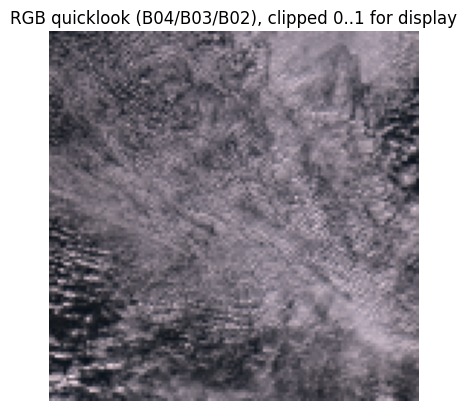

Footprint fraction (any band > 0): 1.0


In [34]:
def read_band_out_reflectance(jp2_path: str) -> np.ndarray:
    if USE_DEBUG_DOWNSCALE:
        dbg = masked_mean_downscale_debug(
            jp2_path, OUT_DIM, QUANTIFICATION_VALUE,
            coverage_threshold=COVERAGE_THRESHOLD, resampling=Resampling.average
        )
        return dbg["out_ref"]

    # FAST PATH (no change to reflectance definition; just avoids full reprojection)
    with rasterio.open(jp2_path) as src:
        dn_ds = src.read(
            1,
            out_shape=(OUT_DIM, OUT_DIM),
            resampling=Resampling.average
        ).astype(np.float32)

    out_ref = dn_ds / float(QUANTIFICATION_VALUE)
    return out_ref


r = read_band_out_reflectance(band_local_paths["B04"])
g = read_band_out_reflectance(band_local_paths["B03"])
b = read_band_out_reflectance(band_local_paths["B02"])

rgb = np.stack([r,g,b], axis=-1)
valid = np.isfinite(rgb).all(axis=-1)

rgb_plot = np.clip(rgb, 0.0, 1.0)
print(rgb_plot)
plt.figure()
plt.title("RGB quicklook (B04/B03/B02), clipped 0..1 for display")
plt.imshow(rgb_plot)
plt.axis("off")
plt.show()

print("Footprint fraction (any band > 0):", float(((rgb>0) & np.isfinite(rgb)).any(axis=2).mean()))


Build the cube

In [35]:
def build_cube_local(bands: List[str], band_local_paths: Dict[str, str]) -> np.ndarray:
    arrays = []
    for band in bands:
        arr = read_band_out_reflectance(band_local_paths[band])
        arrays.append(arr)
    return np.stack(arrays, axis=-1)  # (y, x, band)

Parallelise the workers

In [36]:
def process_one_product_id(pid: str, use_debug_downscale: bool) -> tuple[str, np.datetime64, np.ndarray]:
    global USE_DEBUG_DOWNSCALE
    USE_DEBUG_DOWNSCALE = use_debug_downscale

    t = sensing_time_from_product_id(pid)
    sensing_date = sensing_date_from_product_id(pid)

    # Same style as notebook 1: make a client inside the worker task
    s3_local = boto3.Session(
        profile_name=AWS_PROFILE,
        region_name=AWS_REGION
    ).client("s3", config=S3_CONFIG)

    tmp_i = tempfile.mkdtemp(prefix="ai4qc2_worker_")
    local_dir = os.path.join(tmp_i, pid)
    os.makedirs(local_dir, exist_ok=True)

    try:
        tiles_prefix = tile_to_tiles_prefix(get_mgrs_tile_from_product_id(pid), sensing_date)
        all_keys = list_s3_objects_requester_pays(s3_local, IN_BUCKET, tiles_prefix)
        band_to_key = find_jp2_band_keys(all_keys, BANDS)

        band_local_paths = {}

        def _dl_one(item):
            band, key = item
            p = os.path.join(local_dir, os.path.basename(key))
            download_s3_object_requester_pays(s3_local, IN_BUCKET, key, p)
            return band, p

        with ThreadPoolExecutor(max_workers=DL_THREADS_PER_WORKER) as tpex:
            for band, p in tpex.map(_dl_one, band_to_key.items()):
                band_local_paths[band] = p

        cube_i = build_cube_local(BANDS, band_local_paths)
        return pid, t, cube_i

    finally:
        shutil.rmtree(tmp_i, ignore_errors=True)

def process_one_scene_task(task: tuple, use_debug_downscale: bool) -> tuple[str, np.datetime64, np.ndarray]:
    global USE_DEBUG_DOWNSCALE
    USE_DEBUG_DOWNSCALE = use_debug_downscale

    pid, t, band_hrefs = task

    s3_local = get_process_s3_client()

    tmp_i = tempfile.mkdtemp(prefix="ai4qc2_worker_")
    local_dir = os.path.join(tmp_i, pid)
    os.makedirs(local_dir, exist_ok=True)

    try:
        band_local_paths = {}

        def _dl_one(item):
            band, href = item
            bucket, key = parse_s3_uri(href)
            p = os.path.join(local_dir, os.path.basename(key))
            download_s3_object_requester_pays(s3_local, bucket, key, p)
            return band, p

        with ThreadPoolExecutor(max_workers=DL_THREADS_PER_WORKER) as tpex:
            for band, p in tpex.map(_dl_one, band_hrefs.items()):
                band_local_paths[band] = p

        cube_i = build_cube_local(BANDS, band_local_paths)
        return pid, t, cube_i

    finally:
        shutil.rmtree(tmp_i, ignore_errors=True)

def process_one_scene(scene_rec: dict, use_debug_downscale: bool) -> tuple[str, np.datetime64, np.ndarray]:
    global USE_DEBUG_DOWNSCALE
    USE_DEBUG_DOWNSCALE = use_debug_downscale

    pid = scene_rec["product_id"]
    t = scene_rec["datetime"]
    band_hrefs = scene_rec["band_hrefs"]

    s3_local = get_process_s3_client()

    tmp_i = tempfile.mkdtemp(prefix="ai4qc2_worker_")
    local_dir = os.path.join(tmp_i, pid)
    os.makedirs(local_dir, exist_ok=True)

    try:
        band_local_paths = {}

        def _dl_one(item):
            band, href = item
            bucket, key = parse_s3_uri(href)
            p = os.path.join(local_dir, os.path.basename(key))
            download_s3_object_requester_pays(s3_local, bucket, key, p)
            return band, p

        with ThreadPoolExecutor(max_workers=DL_THREADS_PER_WORKER) as tpex:
            for band, p in tpex.map(_dl_one, band_hrefs.items()):
                band_local_paths[band] = p

        cube_i = build_cube_local(BANDS, band_local_paths)
        return pid, t, cube_i

    finally:
        shutil.rmtree(tmp_i, ignore_errors=True)

Zarr stacking helper methods

In [37]:
def write_debug_single_time_zarr(
    band_names, band_local_paths, product_id, safe_prefix, tile,
    out_dim, quant_val, cov_thresh, in_bucket, tmp_dir
):
    cube = build_cube_local(band_names, band_local_paths)
    t0 = sensing_time_from_product_id(product_id)
    debug_pid = safe_prefix_to_product_id(safe_prefix)

    ds = xr.Dataset(
        data_vars={"reflectance": (["time", "y", "x", "band"], cube[None, ...])},
        coords={
            "time": ("time", np.array([t0])),
            "y": np.arange(cube.shape[0]),
            "x": np.arange(cube.shape[1]),
            "band": np.arange(cube.shape[2]),
            "band_name": ("band", band_names),
            "system_index": ("time", np.array([debug_pid], dtype=f"U{len(debug_pid)}")),
        },
        attrs={
            "mgrs_tile": tile,
            "processing": "Masked-mean downscaling: average(DN*valid)/average(valid) using read_masks; DN scaled to reflectance",
            "quantification_value_divisor": float(quant_val),
            "coverage_threshold": float(cov_thresh),
            "out_dim": int(out_dim),
            "source_bucket": in_bucket,
            "note": "This dataset is the DEBUG product only (time dimension length=1).",
        },
    )

    out_path = os.path.join(tmp_dir, "debug_out_single_time.zarr")
    ds = ds.chunk({"time": 1, "y": out_dim, "x": out_dim, "band": len(band_names)})
    ds.to_zarr(out_path, mode="w", consolidated=True)
    return out_path


def load_existing_store_state(local_zarr):
    """Return (wrote, existing_set, pid_dtype_len_from_store_or_None, time_chunk_or_None, ds_existing_or_None)."""
    if not os.path.exists(local_zarr):
        return False, set(), None, None, None

    try:
        ds_existing = xr.open_zarr(local_zarr, consolidated=False)
        store_u = ds_existing["system_index"].dtype.itemsize // 4  # U len
        existing = set(map(str, ds_existing["system_index"].values.tolist()))
        time_chunk = int(ds_existing["reflectance"].chunks[0][0])
        return True, existing, store_u, time_chunk, ds_existing
    except Exception as e:
        print(f"[WARN] Could not open existing Zarr for resume: {e!r}")
        return False, set(), None, None, None


def dedup_scene_records(scene_records):
    seen = set()
    unique = []
    for rec in scene_records:
        pid = rec["product_id"]
        if pid not in seen:
            seen.add(pid)
            unique.append(rec)
    return unique


def compute_georef_once(
    s3, in_bucket, tile, out_dim,
    scene_records, existing,
):
    """Compute x/y/crs/transform from first new timestep using B02 from scene_records."""
    scene0 = None
    for rec in scene_records:
        if rec["product_id"] not in existing:
            scene0 = rec
            break

    if scene0 is None:
        return None, None, None, None

    b02_href = scene0["band_hrefs"]["B02"]
    bucket0, key0 = parse_s3_uri(b02_href)

    tmp0 = tempfile.mkdtemp(prefix="ai4qc2_georef_")
    try:
        b02_path0 = os.path.join(tmp0, "B02.jp2")
        download_s3_object_requester_pays(s3, bucket0, key0, b02_path0)

        with rasterio.open(b02_path0) as src:
            crs_wkt = src.crs.to_wkt()
            transform = src.transform
            dst_transform = transform * Affine.scale(src.width / out_dim, src.height / out_dim)

        cols = np.arange(out_dim)
        rows = np.arange(out_dim)
        x_easting, _ = dst_transform * (cols + 0.5, np.zeros_like(cols) + 0.5)
        _, y_northing = dst_transform * (np.zeros_like(rows) + 0.5, rows + 0.5)

        return (
            np.asarray(x_easting, dtype=np.float64),
            np.asarray(y_northing, dtype=np.float64),
            crs_wkt,
            dst_transform,
        )
    finally:
        shutil.rmtree(tmp0, ignore_errors=True)


def make_ds_block(pids, times, cubes, band_names, out_dim, pid_dtype_len, x_easting, y_northing, time_chunk):
    block_f32 = np.stack(cubes, axis=0).astype(np.float32)  # reflectance float32

    if MODE == "RGB_UINT16":
        # Store reflectance scaled to uint16 (0..1 mapped to 0..10000)
        STORE_SCALE = 10000.0
        block_u16 = np.rint(np.clip(block_f32, 0.0, 1.0) * STORE_SCALE).astype(np.uint16)
        out_data = block_u16
    else:
        out_data = block_f32

    pid_u = np.array(pids, dtype=f"U{pid_dtype_len}")
    t_ns = np.array(times, dtype="datetime64[ns]")

    ds = xr.Dataset(
        data_vars={"reflectance": (["time", "y", "x", "band"], out_data)},
        coords={
            "time": ("time", t_ns),
            "y": ("y", y_northing),
            "x": ("x", x_easting),
            "band": np.arange(len(band_names)),
            "band_name": ("band", band_names),
            "system_index": ("time", pid_u),
        },
    )

    ds = ds.chunk({"time": min(time_chunk, out_data.shape[0]), "y": out_dim, "x": out_dim, "band": len(band_names)})

    ds["x"].attrs.update({"standard_name": "projection_x_coordinate", "units": "m"})
    ds["y"].attrs.update({"standard_name": "projection_y_coordinate", "units": "m"})
    ds["time"].encoding = {
        "units": "nanoseconds since 1970-01-01 00:00:00",
        "calendar": "proleptic_gregorian",
        "dtype": "int64",
    }
    if MODE == "RGB_UINT16":
        ds["reflectance"].attrs.update({
            "stored_as": "uint16_scaled",
            "packing_scale_factor": 1.0 / STORE_SCALE,
            "packing_add_offset": 0.0,
            "packing_note": "Recover reflectance_float = reflectance_uint16 * packing_scale_factor + packing_add_offset",
        })
    return ds


def finalize_store_attrs(local_zarr, crs_wkt=None, dst_transform=None):
    ds_final = xr.open_zarr(local_zarr, consolidated=False, decode_times=False)
    tvals = ds_final["time"].values.astype("int64")

    attrs = dict(ds_final.attrs)
    if tvals.size:
        attrs.update({"time_start_ns": int(tvals.min()), "time_end_ns": int(tvals.max()), "num_timesteps": int(tvals.size)})
    else:
        attrs.update({"num_timesteps": 0})

    if (crs_wkt is not None) and (dst_transform is not None):
        attrs.update({
            "crs_wkt": crs_wkt,
            "dst_transform_gdal": tuple(dst_transform.to_gdal()),
            "dst_transform_affine": [dst_transform.a, dst_transform.b, dst_transform.c,
                                     dst_transform.d, dst_transform.e, dst_transform.f],
        })

    ds_final.assign_attrs(attrs).to_zarr(local_zarr, mode="a", consolidated=True)

## 7) Optional: write Zarr locally (no upload)
This writes the same dataset structure your script writes, but to a local folder so you can open and inspect quickly.

In [38]:
# (A) DEBUG single-time Zarr
OUTPUT_DIR = os.getcwd()

import time
t_start = time.time()
n_done = 0

# (B) FULL time-stacked cube
BUILD_TIME_STACK = True
if not BUILD_TIME_STACK:
    raise SystemExit("Time stack build disabled.")

local_time_zarr = os.path.join(OUTPUT_DIR, ZARR_NAME)

wrote, existing, store_u, time_chunk_existing, _ = load_existing_store_state(local_time_zarr)
pid_dtype_len = store_u if store_u is not None else PID_DTYPE_LEN

TIME_CHUNK = time_chunk_existing if (time_chunk_existing is not None) else (BATCH_SIZE if USE_BATCH_WRITES else 1)
print("Resume:", wrote, "| existing:", len(existing), "| pid dtype:", pid_dtype_len, "| time_chunk:", TIME_CHUNK)

scene_records = dedup_scene_records(scene_records)
print("Scene records after dedup:", len(scene_records))

x_easting, y_northing, crs_wkt, dst_transform = compute_georef_once(
    s3, IN_BUCKET, TILE, OUT_DIM, scene_records, existing
)
if x_easting is None:
    print("Nothing new to process (all in existing).")
    local_time_zarr

base_attrs = {
    "mgrs_tile": TILE,
    "processing": "...",
    "quantification_value_divisor": float(QUANTIFICATION_VALUE),
    "coverage_threshold": float(COVERAGE_THRESHOLD),
    "scene_filter_enabled": bool(ENABLE_SCENE_FILTER),
    "scene_filter_min_valid_fraction": float(MIN_VALID_FRACTION),
    "scene_filter_type": "l1c_tileinfo",
    "out_dim": int(OUT_DIM),
    "source_bucket": IN_BUCKET,
}
if (crs_wkt is not None) and (dst_transform is not None):
    base_attrs.update({"crs_wkt": crs_wkt, "dst_transform_gdal": tuple(dst_transform.to_gdal())})

to_submit = sorted(
    [rec for rec in scene_records if rec["product_id"] not in existing],
    key=lambda rec: extract_datetime_token(rec["product_id"])
)
print(f"Submitting {len(to_submit)} timesteps to {MAX_WORKERS} workers...")

failure_log = os.path.join(OUTPUT_DIR, "failures.jsonl")
batch_pids, batch_times, batch_cubes = [], [], []

with ProcessPoolExecutor(max_workers=MAX_WORKERS) as ex:
    for j, (pid, t, cube_i) in enumerate(
        ex.map(process_one_scene, to_submit, [False] * len(to_submit)),
        start=1
    ):
        try:
            if pid in existing or pid in batch_pids:
                continue
            if len(pid) > pid_dtype_len:
                raise ValueError(f"pid too long for store dtype U{pid_dtype_len}: {pid} (len={len(pid)})")

            batch_pids.append(pid)
            batch_times.append(t)
            batch_cubes.append(cube_i)

            should_flush = (not USE_BATCH_WRITES) or (len(batch_pids) >= BATCH_SIZE)
            if should_flush:
                ds_block = make_ds_block(
                    batch_pids, batch_times, batch_cubes,
                    BANDS, OUT_DIM, pid_dtype_len, x_easting, y_northing, TIME_CHUNK
                )

                if not wrote:
                    ds_block.assign_attrs(base_attrs).to_zarr(local_time_zarr, mode="w", consolidated=True)
                    wrote = True
                else:
                    ds_block.to_zarr(local_time_zarr, mode="a", append_dim="time", consolidated=False)

                flushed = len(batch_pids)
                existing.update(batch_pids)
                batch_pids, batch_times, batch_cubes = [], [], []

                n_done += flushed
                elapsed = time.time() - t_start
                rate = n_done / (elapsed / 60.0)
                print(f"Wrote {n_done} timesteps in {elapsed/60:.1f} min => {rate:.2f} timesteps/min")

            if j % 25 == 0:
                print(f"Processed {j}/{len(to_submit)} timesteps")

        except Exception as e:
            log_failure(failure_log, pid if "pid" in locals() else "UNKNOWN", stage="parallel_bulk", err=e)
            print(f"[WARN] parallel timestep failed: {e!r}")

if batch_pids:
    ds_block = make_ds_block(
        batch_pids, batch_times, batch_cubes,
        BANDS, OUT_DIM, pid_dtype_len, x_easting, y_northing, TIME_CHUNK
    )
    if not wrote:
        ds_block.assign_attrs(base_attrs).to_zarr(local_time_zarr, mode="w", consolidated=True)
        wrote = True
    else:
        ds_block.to_zarr(local_time_zarr, mode="a", append_dim="time", consolidated=False)
    existing.update(batch_pids)

if wrote:
    finalize_store_attrs(local_time_zarr, crs_wkt=crs_wkt, dst_transform=dst_transform)

local_time_zarr

Resume: False | existing: 0 | pid dtype: 128 | time_chunk: 128
Scene records after dedup: 667
Submitting 667 timesteps to 12 workers...
Processed 25/667 timesteps
Processed 50/667 timesteps
Processed 75/667 timesteps
Processed 100/667 timesteps
Processed 125/667 timesteps


/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=3, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=128, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr 

Wrote 128 timesteps in 0.9 min => 148.66 timesteps/min
Processed 150/667 timesteps
Processed 175/667 timesteps
Processed 200/667 timesteps
Processed 225/667 timesteps
Processed 250/667 timesteps


/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=128, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


Wrote 256 timesteps in 1.5 min => 165.34 timesteps/min
Processed 275/667 timesteps
Processed 300/667 timesteps
Processed 325/667 timesteps
Processed 350/667 timesteps
Processed 375/667 timesteps


...

Wrote 512 timesteps in 2.8 min => 181.21 timesteps/min
Processed 525/667 timesteps
Processed 550/667 timesteps
Processed 575/667 timesteps
Processed 600/667 timesteps
Processed 625/667 timesteps


/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=128, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


Wrote 640 timesteps in 3.5 min => 181.80 timesteps/min
Processed 650/667 timesteps


/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=128, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/ubuntu/AI4QC2_HIGH/.venv/lib/python3.12/site-packages/zarr/c

'/home/ubuntu/AI4QC2_HIGH/s2_l1c_tile_31TCJ_2015-06-01_to_2025-12-31_RGB_FLOAT.zarr'

## 8) Cleanup
Delete the temporary download folder when you're done.

Quick structural sanity checks

In [39]:
import xarray as xr
import numpy as np

z = os.path.join(OUTPUT_DIR, ZARR_NAME)
ds = xr.open_zarr(z, consolidated=False)

print(ds)
print("dims:", ds.dims)
print("reflectance dtype:", ds["reflectance"].dtype)
print("reflectance shape:", ds["reflectance"].shape)
print("band_name:", ds["band_name"].values.tolist())
print("time count:", ds.dims["time"])
print("time min/max:", ds["time"].values.min(), ds["time"].values.max())
print("unique system_index count:", len(np.unique(ds["system_index"].values)))


<xarray.Dataset> Size: 131MB
Dimensions:       (time: 667, y: 128, x: 128, band: 3)
Coordinates:
  * time          (time) datetime64[ns] 5kB 2016-11-07 2016-11-17 ... 2025-12-30
  * y             (y) float64 1kB 4.9e+06 4.899e+06 ... 4.792e+06 4.791e+06
  * x             (x) float64 1kB 3.004e+05 3.013e+05 ... 4.085e+05 4.094e+05
  * band          (band) int64 24B 0 1 2
    band_name     (band) <U3 36B dask.array<chunksize=(3,), meta=np.ndarray>
    system_index  (time) <U128 342kB dask.array<chunksize=(128,), meta=np.ndarray>
Data variables:
    reflectance   (time, y, x, band) float32 131MB dask.array<chunksize=(128, 128, 128, 3), meta=np.ndarray>
Attributes:
    time_start_ns:         1478476800000000000
    time_end_ns:           1767052800000000000
    num_timesteps:         667
    crs_wkt:               PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DAT...
    dst_transform_gdal:    [300000.0, 857.8125, 0.0, 4900020.0, 0.0, -857.8125]
    dst_transform_affine:  [857.8125, 0.0, 3

/tmp/ipykernel_2754111/3016523381.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("time count:", ds.dims["time"])


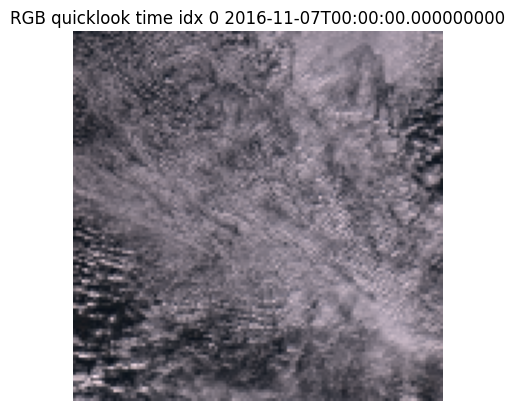

In [48]:
import matplotlib.pyplot as plt

tidx = 0
B04 = int(np.where(ds["band_name"].values == "B04")[0][0])
B03 = int(np.where(ds["band_name"].values == "B03")[0][0])
B02 = int(np.where(ds["band_name"].values == "B02")[0][0])

rgb = np.stack([
    ds["reflectance"].isel(time=tidx, band=B04).values,
    ds["reflectance"].isel(time=tidx, band=B03).values,
    ds["reflectance"].isel(time=tidx, band=B02).values,
], axis=-1)

plt.figure()
plt.title(f"RGB quicklook time idx {tidx} {ds['time'].values[tidx]}")
plt.imshow(np.clip(rgb, 0, 1))
plt.axis("off")
plt.show()


In [49]:
from pathlib import Path

zarr_path = os.path.join(OUTPUT_DIR, ZARR_NAME)

total_bytes = 0
file_count = 0

for p in Path(zarr_path).rglob("*"):
    if p.is_file():
        total_bytes += p.stat().st_size
        file_count += 1

size_gb = total_bytes / (1024**3)

print("Size (GB):", size_gb)
print("Number of files:", file_count)

Size (GB): 0.07596168667078018
Number of files: 30


In [50]:
import subprocess
import time
from pathlib import Path

# ---- measure zarr size again (safe to recompute) ----
zarr_path = Path(local_time_zarr)

total_bytes = 0
file_count = 0

for p in zarr_path.rglob("*"):
    if p.is_file():
        total_bytes += p.stat().st_size
        file_count += 1

size_mb = total_bytes / (1024**2)
size_gb = total_bytes / (1024**3)

print(f"Zarr size: {size_mb:.2f} MB ({size_gb:.4f} GB)")
print(f"File count: {file_count}")

# ---- upload to S3 and measure time ----
bucket = "s3://ai4qc2-high-compute-sentinel-zarr/zarr-test/"
local_path = local_time_zarr

t0 = time.time()

subprocess.run(
    ["aws", "s3", "cp", local_path, bucket, "--recursive"],
    check=True
)

elapsed = time.time() - t0

print(f"\nUpload time: {elapsed:.2f} seconds")
print(f"Upload time: {elapsed/60:.2f} minutes")

# ---- upload speed ----
print(f"Approx upload speed: {size_mb / elapsed:.2f} MB/s")

Zarr size: 77.78 MB (0.0760 GB)
File count: 30
upload: s2_l1c_tile_31TCJ_2015-06-01_to_2025-12-31_RGB_FLOAT.zarr/band/c/0 to s3://ai4qc2-high-compute-sentinel-zarr/zarr-test/band/c/0
upload: s2_l1c_tile_31TCJ_2015-06-01_to_2025-12-31_RGB_FLOAT.zarr/band/zarr.json to s3://ai4qc2-high-compute-sentinel-zarr/zarr-test/band/zarr.json
upload: s2_l1c_tile_31TCJ_2015-06-01_to_2025-12-31_RGB_FLOAT.zarr/band_name/c/0 to s3://ai4qc2-high-compute-sentinel-zarr/zarr-test/band_name/c/0
upload: s2_l1c_tile_31TCJ_2015-06-01_to_2025-12-31_RGB_FLOAT.zarr/band_name/zarr.json to s3://ai4qc2-high-compute-sentinel-zarr/zarr-test/band_name/zarr.json
upload: s2_l1c_tile_31TCJ_2015-06-01_to_2025-12-31_RGB_FLOAT.zarr/reflectance/zarr.json to s3://ai4qc2-high-compute-sentinel-zarr/zarr-test/reflectance/zarr.json
upload: s2_l1c_tile_31TCJ_2015-06-01_to_2025-12-31_RGB_FLOAT.zarr/reflectance/c/0/0/0/0 to s3://ai4qc2-high-compute-sentinel-zarr/zarr-test/reflectance/c/0/0/0/0
upload: s2_l1c_tile_31TCJ_2015-06-01_to_2